# Benchmark Evaluation Notebook - Single SBML

_Adapted from Jonah R. Huggins_

Execute the first cell below, others can be executed in any order after.

In [9]:
# Packages import
import os
import sys
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings; warnings.simplefilter('ignore')
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "DejaVu Sans"

# Get the directory path
wd = os.path.dirname(os.getcwd())

# Create the formatted path to the SPARCED input files
project_root = ('.')

sys.path.append(os.path.join(project_root))

from viz_helpers import *

#os.chdir(os.path.join(project_root, 'benchmarks'))

# Set global font to Arial
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 14,            # default size for all text
    'axes.titlesize': 16,       # axes title size
    'axes.labelsize': 14,       # x/y label size
    'xtick.labelsize': 12,      # x tick label size
    'ytick.labelsize': 12,      # y tick label size
    'legend.fontsize': 12       # legend font size
})

#prompt user for the date of simulation
def get_data_title():
    """Basic function for prompting the user for the benchmark's name. Applied 
    In Every Benchmark Cell."""
    return input('Enter the name of the simulation, default is date of (YYYY-MM-DD): ')

### Receptor-Ligand Cooperativity Benchmark
[Compare to Erdem et al. Supp. Fig. 3A](https://www.nature.com/articles/s41467-022-31138-1#MOESM1) \
Simulated ligand-receptor cooperativity coefficients for the receptor tyrosine kinases match experimental observations (negative cooperativity: EGF, FGF, IGF, INS; no cooperativity: HGF, NRG1, and positive cooperativity: PDGF).

In [5]:
with open(f'receptor-ligand-cooperativity/receptor-ligand-cooperativity.pkl', 'rb') as f:
    data = pickle.load(f)


ligInds = [155,156,157,158,159,160,161]
ligConc = [0.001,0.01,0.1,1,10,100,1000]

conds = {}

observables = [
    'EE1_species',  #SP Start
    'HE3_species', 'HE4_species', 'HGF_species', 
    'Ppr_species', 'Ffr_species', #SP End
    'EE1E2_species', #SPP Start
    'EE1E1_species', 'EE1E3_species','EE1E4_species', 
    'E2HE3_species', 'E1HE3_species', 'HE3E3_species', 
    'HE3E4_species', 'E2HE4_species', 'E1HE4_species', 
    'E3HE4_species', 'HE4E4_species', 'HGF_Met_Met_species', 
    'PPrPr_species', 'FFrFr_species', 'IIrIr_species', 
    'INS_Isr_Isr_species', # SPP End
    'EE1EE1_species', #SPSP Start
    'EE1HE3_species', 'EE1HE4_species', 'HE3HE3_species', 
    'HE3HE4_species', 'HE4HE4_species','HGF_Met_HGF_Met_species', 
    'PPrPPr_species', 'FFrFFr_species', 'IIrIrI_species', 
    'INS_Isr_Isr_INS_species' # SPSP End
    ]

for condition in data['receptor-ligand-cooperativity']:
    SPInds = []
    SPPInds = []
    SPSPInds = []
    for obs in observables[:6]:
        SPInds.append(data['receptor-ligand-cooperativity'][condition][obs]['simulation'][-1])
    for obs in observables[6:23]:
        SPPInds.append(data['receptor-ligand-cooperativity'][condition][obs]['simulation'][-1])
    for obs in observables[23:]:
        SPSPInds.append(data['receptor-ligand-cooperativity'][condition][obs]['simulation'][-1])

    ns_prod_sum = sum(SPInds) + sum(SPPInds) + 2.0*sum(SPSPInds)

    conds[condition] = ns_prod_sum


egf_results = list(conds.values())[0:7]
h_results = list(conds.values())[7:14]
hgf_results = list(conds.values())[14:21]
p_results = list(conds.values())[21:28]
f_results = list(conds.values())[28:35]
i_results = list(conds.values())[35:42]
ins_results = list(conds.values())[42:49]

list_of_results = [egf_results, h_results, hgf_results, p_results, f_results, i_results, ins_results]
list_of_ligands = ['EGF', 'H', 'HGF', 'P', 'F', 'I', 'INS']

# Define the Sigmoid-Hill equation
def func(x, a, b, c):
    return a * np.power(x, b) / (np.power(c, b) + np.power(x, b))

# Set global plot attributes
plt.rc('font', size=16, weight='bold')  # Set fontsize and font weight
plt.rc('axes', titlesize=16)             # Set title fontsize
# plt.rc('axes', labelsize=12)             # Set label fontsize
plt.rc('xtick', labelsize=16)            # Set x-axis tick label fontsize
plt.rc('ytick', labelsize=16)            # Set y-axis tick label fontsize
plt.rc('legend', fontsize=16)
# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(9, 11))

hill_curve_data = {}

# Loop through each lig_result and plot on separate subplots
for i, lig_result in enumerate(list_of_results):
    hill_curve_data[list_of_ligands[i]] = {}
    x_data = ligConc
    y_data = lig_result
    # Fit the curve
    params, covariance = curve_fit(func, x_data, y_data, maxfev = 100000)
    a_fit, b_fit, c_fit = params
    y_fit = func(x_data, a_fit, b_fit, c_fit)

    hill_curve_data[list_of_ligands[i]]['x'] = x_data
    hill_curve_data[list_of_ligands[i]]['y'] = y_data
    hill_curve_data[list_of_ligands[i]]['fit'] = y_fit
    hill_curve_data[list_of_ligands[i]]['hill coefficient'] = b_fit


axes[0, 0].scatter(hill_curve_data['EGF']['x'], hill_curve_data['EGF']['y'])
axes[0, 0].plot(hill_curve_data['EGF']['x'], hill_curve_data['EGF']['fit'], \
    label=f'n={hill_curve_data["EGF"]["hill coefficient"]:.1f}', color='blue')
axes[0, 0].set_xlabel("EGF (nM)", weight="bold")
axes[0, 0].set_xscale('log', base=10)
axes[0, 0].legend(frameon=False)

axes[0, 1].scatter(hill_curve_data['H']['x'], hill_curve_data['H']['y'], color='#d9551c')
axes[0, 1].plot(hill_curve_data['H']['x'], hill_curve_data['H']['fit'], \
    label=f'n={hill_curve_data["H"]["hill coefficient"]:.1f}', color='#d9551c')
axes[0, 1].set_xlabel("HRG (nM)", weight="bold")
axes[0, 1].set_xscale('log', base=10)
axes[0, 1].legend(frameon=False)

axes[1, 0].scatter(hill_curve_data['HGF']['x'], hill_curve_data['HGF']['y'], color='#edb120')
axes[1, 0].plot(hill_curve_data['HGF']['x'], hill_curve_data['HGF']['fit'], \
    label=f'n={hill_curve_data["HGF"]["hill coefficient"]:.1f}', color='#edb120')
axes[1, 0].set_xlabel("HGF (nM)", weight="bold")
axes[1, 0].set_xscale('log', base=10)
axes[1, 0].legend(frameon=False)

axes[1, 1].scatter(hill_curve_data['P']['x'], hill_curve_data['P']['y'],color='#813491')
axes[1, 1].plot(hill_curve_data['P']['x'], hill_curve_data['P']['fit'], \
    label=f'n={hill_curve_data["P"]["hill coefficient"]:.1f}', color='#813491')
axes[1, 1].set_xlabel("PDGFB (nM)", weight="bold")
axes[1, 1].set_xscale('log', base=10)
axes[1, 1].legend(frameon=False)

axes[2, 0].scatter(hill_curve_data['F']['x'], hill_curve_data['F']['y'], color='#77ac30')
axes[2, 0].plot(hill_curve_data['F']['x'], hill_curve_data['F']['fit'], \
    label=f'n={hill_curve_data["F"]["hill coefficient"]:.1f}', color='#77ac30')
axes[2, 0].set_xlabel("FGF (nM)", weight="bold")
axes[2, 0].set_xscale('log', base=10)
axes[2, 0].legend(frameon=False)

axes[2, 1].scatter(hill_curve_data['I']['x'], hill_curve_data['I']['y'], color = '#51bfee')
axes[2, 1].plot(hill_curve_data['I']['x'], hill_curve_data['I']['fit'], \
    label=f'n={hill_curve_data["I"]["hill coefficient"]:.1f}', color='#51bfee')
axes[2, 1].set_xlabel("IGF (nM)", weight="bold")
axes[2, 1].set_xscale('log', base=10)
axes[2, 1].legend(frameon=False)

axes[3, 0].scatter(hill_curve_data['INS']['x'], hill_curve_data['INS']['y'], color = '#a2142f')
axes[3, 0].plot(hill_curve_data['INS']['x'], hill_curve_data['INS']['fit'], \
    label=f'n={hill_curve_data["INS"]["hill coefficient"]:.1f}', color='#a2142f')
axes[3, 0].set_xlabel("INS (nM)", weight="bold")
axes[3, 0].set_xscale('log', base=10)
axes[3, 0].legend(frameon=False)


fig.delaxes(axes[3, 1])
# fig.delaxes(axes[2, 1])
plt.tight_layout()

# Show the entire figure
plt.savefig('receptor-ligand-cooperativity.png')

FileNotFoundError: [Errno 2] No such file or directory: 'receptor-ligand-cooperativity/receptor-ligand-cooperativity.pkl'

### Proliferation and Growth Benchmark
[Compare to Erdem et al. Supp. Fig. 4](https://www.nature.com/articles/s41467-022-31138-1#MOESM1) \
EGF and insulin stimulation activates both ERK and AKT pathways. Dual stimulation with the two ligands induces prolonged AKT activation.

KeyError: 'ppERK_total'

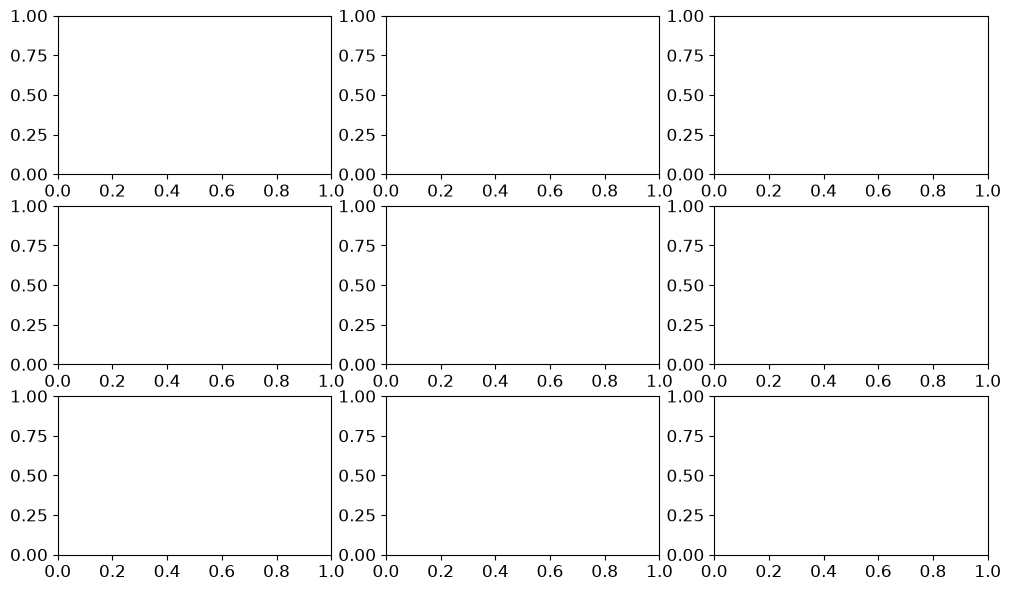

In [10]:
with open(f'proliferation-growth/proliferation-growth.pkl', 'rb') as f:
    data = pickle.load(f)
    
conditions = list(data.keys())

fig, axs = plt.subplots(3, 3, figsize=(12, 7))

treatments = ['EGF \nonly', 'Insulin \nonly', 'EGF + \nInsulin']
observables = ['ppERK (nM)', 'ppAKT (nM)', 'pEIF4BP1 (nM)']
sep_ylims = [120, 40, 10]
colors = ['#0072bd', '#d95319', '#edb120', '#7e2f8e']
leg_labels = ['Lowest dose', 'Low dose', 'Medium dose', 'High dose']

# --- ppERK ---
for condition in conditions[:4]:
    axs[0, 0].plot(
        data[condition]['ppERK_total']['time']/60, 
        data[condition]['ppERK_total']['simulation'], 
        linewidth=4, color = colors[conditions.index(condition)], 
        label = leg_labels[conditions.index(condition)])
    axs[0, 1].plot(
        data[condition]['ppAKT_total']['time']/60, 
        data[condition]['ppAKT_total']['simulation'], 
        linewidth=4, color = colors[conditions.index(condition)], 
        label = leg_labels[conditions.index(condition)])
    axs[0, 2].plot(
        data[condition]['pEIF4BP1_total']['time']/60, 
        data[condition]['pEIF4BP1_total']['simulation'], 
        linewidth=4, color = colors[conditions.index(condition)], 
        label = leg_labels[conditions.index(condition)])

# --- ppAKT ---
for condition in conditions[4:8]:
    idx = conditions.index(condition) - 4
    axs[1, 0].plot(
        data[condition]['ppERK_total']['time']/60, 
        data[condition]['ppERK_total']['simulation'], 
        linewidth=4, color = colors[idx], label = leg_labels[idx])
    axs[1, 1].plot(
        data[condition]['ppAKT_total']['time']/60, 
        data[condition]['ppAKT_total']['simulation'], 
        linewidth=4, color = colors[idx], label = leg_labels[idx])
    axs[1, 2].plot(
        data[condition]['pEIF4BP1_total']['time']/60, 
        data[condition]['pEIF4BP1_total']['simulation'], 
        linewidth=4, color = colors[idx], label = leg_labels[idx])

# --- pEIF4EBP1 ---
for condition in conditions[8:12]:
    idx = conditions.index(condition) - 8
    axs[2, 0].plot(
        data[condition]['ppERK_total']['time']/60, 
        data[condition]['ppERK_total']['simulation'], 
        linewidth=4, color = colors[idx], label = leg_labels[idx])
    axs[2, 1].plot(
        data[condition]['ppAKT_total']['time']/60, 
        data[condition]['ppAKT_total']['simulation'], 
        linewidth=4, color = colors[idx], label = leg_labels[idx])
    axs[2, 2].plot(
        data[condition]['pEIF4BP1_total']['time']/60, 
        data[condition]['pEIF4BP1_total']['simulation'], 
        linewidth=4, color = colors[idx], label = leg_labels[idx])

# --- axis labels, limits, and despine ---
for i in range(3): 
    for j in range(3):
        axs[i, j].set_ylim(0, sep_ylims[j])
        sns.despine(ax=axs[i, j], right=True, top=True)
        axs[i, j].set_ylabel(observables[j], fontsize = 14, weight = 'bold', rotation = 90)

# --- x-axis label for center bottom row ---
axs[2, 1].set_xlabel('Time (min.)', fontsize=20, weight='bold')

# --- legend outside top-right plot ---
axs[0, 2].legend(
    labels=leg_labels, 
    frameon=False, 
    bbox_to_anchor=(1, 1), 
    loc='upper left'
)

fig.text(-0.075, 0.8, treatments[0], fontsize=20, weight='bold')
fig.text(-0.075, 0.5, treatments[1], fontsize=20, weight='bold')
fig.text(-0.075, 0.2, treatments[2], fontsize=20, weight='bold')


plt.tight_layout()
plt.show()


### DNA Repair Benchmark
[Compare to Erdem et al. Supp. Fig. 6a](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
Double and/or single stranded DNA damage activates p53 and DNA damage repair mechanisms represses its response.

KeyError: 'p53_active'

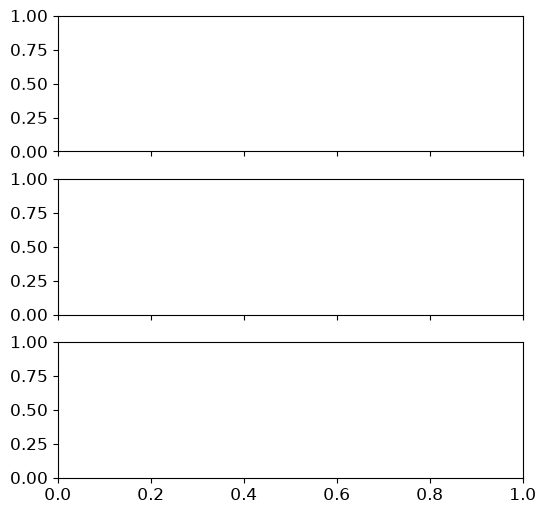

In [11]:
with open(f'DNA-repair/DNA-repair.pkl', 'rb') as f:
    data = pickle.load(f)
    

conds = list(data.keys())

# Set up a 3x1 subplot grid
fig, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

# --- helper to style ticks ---
def style_ticks(ax, axis="both"):
    ax.tick_params(axis=axis, labelsize=14)
    if axis in ["y", "both"]:
        for label in ax.get_yticklabels():
            label.set_fontweight("bold")
    if axis in ["x", "both"]:
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

# Plot single stranded break results
axs[0].plot(data[conds[0]]['p53_active']['time']/3600,
            data[conds[0]]['p53_active']['simulation'],
            label='Without Repair', color='blue', linewidth=4)
axs[0].plot(data[conds[1]]['p53_active']['time']/3600,
            data[conds[1]]['p53_active']['simulation'],
            label='With Repair', color='red', linewidth=4)
axs[0].grid(True)
axs[0].set_ylim(0, 400)
axs[0].set_xticks(np.arange(0, 24, step=6))
axs[0].legend(frameon=False)
axs[0].text(12.50, 350.0, 'Single Stranded DNA damage', fontsize=12)
style_ticks(axs[0])

# Plot double stranded break results
axs[1].plot(data[conds[2]]['p53_active']['time']/3600,
            data[conds[2]]['p53_active']['simulation'],
            label='Without Repair', color='blue', linewidth=4)
axs[1].plot(data[conds[3]]['p53_active']['time']/3600,
            data[conds[3]]['p53_active']['simulation'],
            label='With Repair', color='red', linewidth=4)
axs[1].grid(True)
axs[1].set_xticks(np.arange(0, 24, step=6))
axs[1].set_ylim(0, 1000)
axs[1].text(12.50, 900.0, 'Double Stranded DNA damage', fontsize=12)
style_ticks(axs[1])

# Plot single- and double-stranded break results
axs[2].plot(data[conds[4]]['p53_active']['time']/3600,
            data[conds[4]]['p53_active']['simulation'],
            label='Without Repair', color='blue', linewidth=4)
axs[2].plot(data[conds[5]]['p53_active']['time']/3600,
            data[conds[5]]['p53_active']['simulation'],
            label='With Repair', color='red', linewidth=4)
axs[2].grid(True)
axs[2].set_ylim(0, 1200)
axs[2].text(15.0, 900.0, 'DS + SS DNA damage', fontsize=12)
axs[2].set_xlabel('Time (hrs)', weight='bold', fontsize=20)
style_ticks(axs[2], axis="both")

# Set the y-axis label (shared)
fig.text(-0.05, 0.5, 'Active p53 (nM)', va='center',
         rotation='vertical', weight='bold', fontsize=20)

plt.tight_layout()
fig.savefig(f'DNA-repair/results/{data_name}.png')

### TRAIL Time To Death Benchmark
[Compare to Erdem et al. Supp. Fig. 7ab](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
Increasing simulated TRAIL dose decreases the time it takes to die for an average cell.

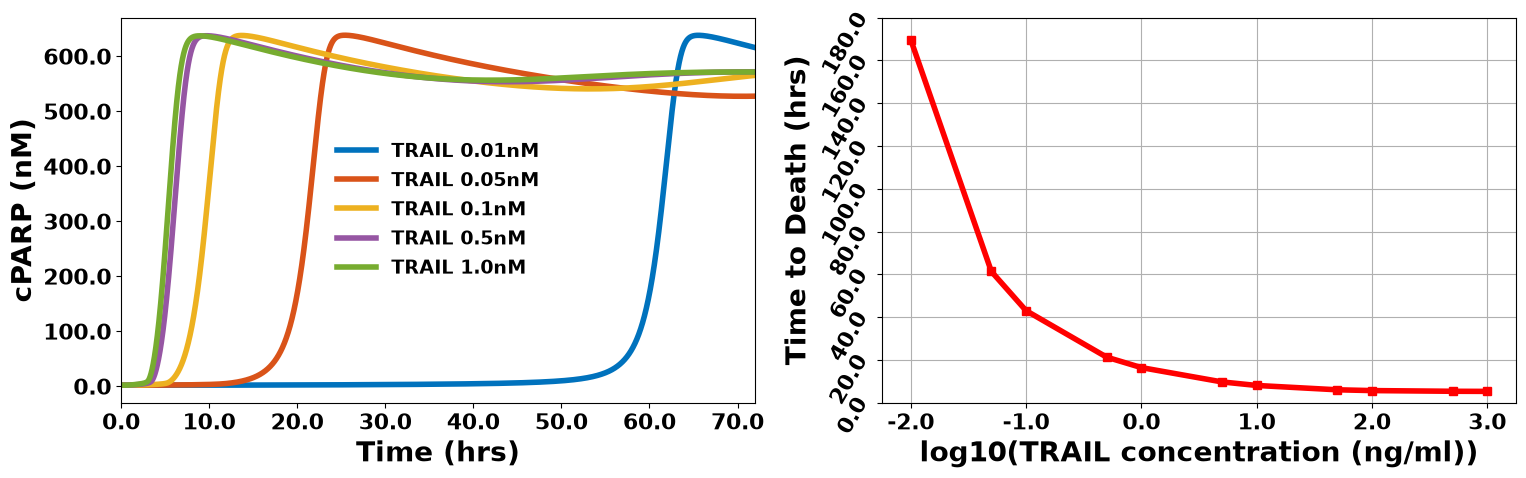

In [13]:
with open(f'./TRAIL-time-to-death/TRAIL-time-to-death.pkl', 'rb') as f:
    data = pickle.load(f)

traildoses = np.array([0.000385, 0.001925, 0.00385, 0.01925, 0.0385, 0.1925, 0.385, 1.9250, 3.85, 19.25, 38.5])
dosesngperml = np.round((traildoses*2.597402597402597e+01), decimals=2)

sims = []
for sim in data['TRAIL-ttd'].keys():
    sims.append(sim)

colors = ["", "#0072bd", "", "#d95319", "", "#edb120", "",  "#9656a3", "", "#77ac30"]

legend = []
for dose in dosesngperml:
    legend.append('TRAIL ' + str(dose) + 'nM')
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
for i in range(1,11,2):

    axs[0].plot(data['TRAIL-ttd'][sims[i]]['cPARP_total']['time']/3600, 
                data['TRAIL-ttd'][sims[i]]['cPARP_total']['simulation'], linewidth=4, color=colors[i])
    axs[0].set_xlim([0, 72])
    axs[0].set_xticklabels(axs[0].get_xticks(), fontsize=16, weight='bold')
    axs[0].set_yticklabels(axs[0].get_yticks(), fontsize=16, weight='bold')
    legend_properties = {'weight':'bold', 'size':14}
    axs[0].legend(labels=legend, loc='best', fontsize=14, frameon=False, prop=legend_properties)

conditions = ["TRAIL_3p85eNeg4", "TRAIL_1p925eNeg3", "TRAIL_3p85eNeg3", "TRAIL_1p925eNeg2", "TRAIL_3p85eNeg2",
              "TRAIL_1p925eNeg1", "TRAIL_3p85eNeg1", "TRAIL_1p925", "TRAIL_3p85", "TRAIL_19p25", "TRAIL_38p5"]

ttd = {cond: 0 for cond in conditions} # time to death

for sim in data['TRAIL-ttd'].keys():

    condition_id = data['TRAIL-ttd'][sim]['conditionId']
    cell = data['TRAIL-ttd'][sim]['cell']

    cparp = data['TRAIL-ttd'][sim]["cPARP_total"]["simulation"].tolist()
    parp = data['TRAIL-ttd'][sim]["PARP_total"]["simulation"].tolist()
    time = data['TRAIL-ttd'][sim]["cPARP_total"]["time"].tolist()

    for idx, (c, p, t) in enumerate(zip(cparp, parp, time)):
        
        if c > p:
            ttd[condition_id] = time[idx]
            break

axs[1].plot(np.log10(dosesngperml),[tod/3600 for tod in ttd.values()],marker='s',linewidth=4, color='red')
axs[1].set_xticklabels(axs[1].get_xticks(), fontsize=16, weight='bold')
axs[1].set_ylim(ymin=0.0, ymax=180.0)
axs[1].set_yticklabels(axs[1].get_yticks(), fontsize=16, weight='bold', rotation=60)
axs[1].grid(True)

# Set the x-axis label
axs[1].set_xlabel('log10(TRAIL concentration (ng/ml))', weight='bold', fontsize=20)
axs[1].set_ylabel( 'Time to Death (hrs)', va='center', rotation='vertical',
                    weight='bold', fontsize=20, labelpad=15)
axs[0].set_xlabel('Time (hrs)', weight='bold', fontsize=20)
axs[0].set_ylabel('cPARP (nM)', weight='bold', fontsize=20)


fig.savefig(f'../TRAIL-time-to-death.png', dpi=300, bbox_inches='tight')

### Survival Signaling Benchmark
[Compare to Erdem et al. Supp. Fig. 7d](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
Increasing ERK and AKT activity levels prolongs TRAIL induced time to death, whereas increasing PUMA and NOXA expression levels decreases the time it takes for cells to die.

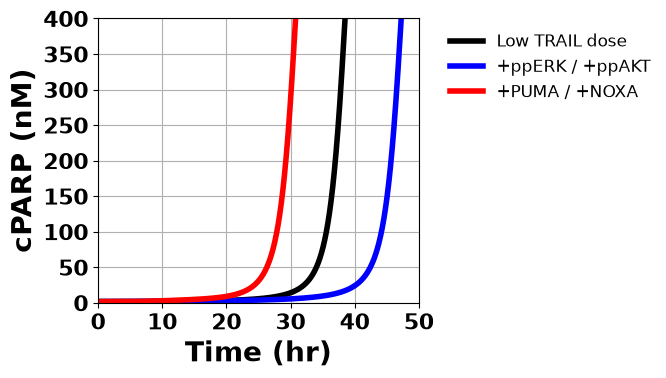

In [14]:
with open(f'survival-signaling/survival-signaling.pkl', 'rb') as f:
    data = pickle.load(f)

conditions = []
for condition in data['survival-signaling']:
    conditions.append(condition)

plt.figure(figsize=(7, 4))
plt.plot(data['survival-signaling'][conditions[0]]['cPARP_total']['time']/3600, 
         data['survival-signaling'][conditions[0]]['cPARP_total']['simulation'], label='TRAIL only', linewidth=4, color='black')
plt.plot(data['survival-signaling'][conditions[1]]['cPARP_total']['time']/3600, 
         data['survival-signaling'][conditions[1]]['cPARP_total']['simulation'], label='+ppERK/+ppAKT', linewidth=4, color='blue')
plt.plot(data['survival-signaling'][conditions[2]]['cPARP_total']['time']/3600, 
         data['survival-signaling'][conditions[2]]['cPARP_total']['simulation'], label='+PUMA/+NOXA', linewidth=4, color='red')
plt.xlabel('Time (hr)', fontsize=20, weight='bold')
plt.ylabel('cPARP (nM)', fontsize=20, weight='bold')
plt.grid(True)
plt.xlim(0, 50)
plt.ylim(0, 400)
plt.xticks(fontsize=16, weight='bold')
plt.yticks(fontsize=16, weight='bold')
plt.legend(['Low TRAIL dose','+ppERK / +ppAKT','+PUMA / +NOXA'], bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(f'survival-signaling.png'), dpi=300)

### Cell Cycle Benchmark
[Compare to Erdem et al. Supp Fig. 8a](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
Increasing Cyclin D mRNA levels induces proper cyclin-CDK complex progression and oscillations for cell cycle entry and progression.

FileNotFoundError: [Errno 2] No such file or directory: 'results/cell_cycle.png'

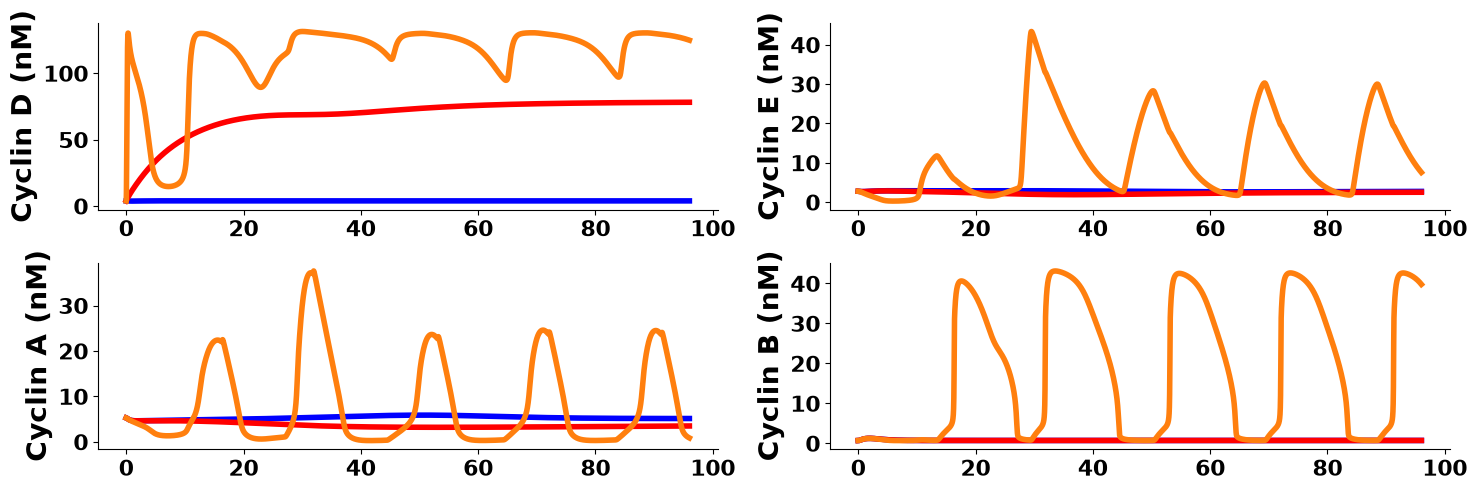

In [16]:
with open(f'cell_cycle/cell_cycle.pkl', 'rb') as f:
    data = pickle.load(f)

conditions = []
for key in data['cell-cycle']:
    conditions.append(key)

fig, ax = plt.subplots(2,2, figsize=(15,5))
#Cyclin D plot
ax[0,0].plot(data['cell-cycle'][conditions[0]]['Cd_total']['time']/3600, data['cell-cycle'][conditions[0]]['Cd_total']['simulation'], linewidth=4, color='b')
ax[0,0].plot(data['cell-cycle'][conditions[1]]['Cd_total']['time']/3600, data['cell-cycle'][conditions[1]]['Cd_total']['simulation'], linewidth=4, color='r')
ax[0,0].plot(data['cell-cycle'][conditions[2]]['Cd_total']['time']/3600, data['cell-cycle'][conditions[2]]['Cd_total']['simulation'], linewidth=4, color='tab:orange')
ax[0,0].set_yticklabels(ax[0,0].get_yticks().astype(int), weight='bold', fontsize=16)
ax[0,0].spines[['right', 'top']].set_visible(False)
ax[0,0].set_xticklabels(ax[0,0].get_xticks().astype(int), weight='bold', fontsize=16)
ax[0,0].set_ylabel('Cyclin D (nM)', weight='bold', fontsize=20)

#Cyclin E plot
ax[0,1].plot(data['cell-cycle'][conditions[0]]['Ce_total']['time']/3600, data['cell-cycle'][conditions[0]]['Ce_total']['simulation'], linewidth=4, color='b')
ax[0,1].plot(data['cell-cycle'][conditions[1]]['Ce_total']['time']/3600, data['cell-cycle'][conditions[1]]['Ce_total']['simulation'], linewidth=4, color='r')
ax[0,1].plot(data['cell-cycle'][conditions[2]]['Ce_total']['time']/3600, data['cell-cycle'][conditions[2]]['Ce_total']['simulation'], linewidth=4, color='tab:orange')
ax[0,1].set_yticklabels(ax[0,1].get_yticks().astype(int), weight='bold', fontsize=16)
ax[0,1].set_xticklabels(ax[0,1].get_xticks().astype(int), weight='bold', fontsize=16)
ax[0,1].spines[['right', 'top']].set_visible(False)
ax[0,1].set_ylabel('Cyclin E (nM)', weight='bold', fontsize=20)
# ax[0,1].legend(['x1', 'x10', 'x60'], title = 'Basal Cyclin D mRNA', 
#                bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=16)

#Cyclin A plot
ax[1,0].plot(data['cell-cycle'][conditions[0]]['Ca_total']['time']/3600, data['cell-cycle'][conditions[0]]['Ca_total']['simulation'], linewidth=4, color='b')
ax[1,0].plot(data['cell-cycle'][conditions[1]]['Ca_total']['time']/3600, data['cell-cycle'][conditions[1]]['Ca_total']['simulation'], linewidth=4, color='r')
ax[1,0].plot(data['cell-cycle'][conditions[2]]['Ca_total']['time']/3600, data['cell-cycle'][conditions[2]]['Ca_total']['simulation'], linewidth=4, color='tab:orange')
ax[1,0].set_yticklabels(ax[1,0].get_yticks().astype(int), weight='bold', fontsize=16)
ax[1,0].set_xticklabels(ax[1,0].get_xticks().astype(int), weight='bold', fontsize=16)
ax[1,0].spines[['right', 'top']].set_visible(False)
ax[1,0].set_ylabel('Cyclin A (nM)', weight='bold', fontsize=20)

#Cyclin B plot
ax[1,1].plot(data['cell-cycle'][conditions[0]]['Cb_total']['time']/3600, data['cell-cycle'][conditions[0]]['Cb_total']['simulation'], linewidth=4, color='b')
ax[1,1].plot(data['cell-cycle'][conditions[1]]['Cb_total']['time']/3600, data['cell-cycle'][conditions[1]]['Cb_total']['simulation'], linewidth=4, color='r')
ax[1,1].plot(data['cell-cycle'][conditions[2]]['Cb_total']['time']/3600, data['cell-cycle'][conditions[2]]['Cb_total']['simulation'], linewidth=4, color='tab:orange')
ax[1,1].set_yticklabels(ax[1,1].get_yticks().astype(int), weight='bold', fontsize=16)
ax[1,1].set_xticklabels(ax[1,1].get_xticks().astype(int), weight='bold', fontsize=16)
ax[1,1].set_ylabel('Cyclin B (nM)', weight='bold', fontsize=20)
ax[1,1].spines[['right', 'top']].set_visible(False)

fig.tight_layout()
fig.savefig(f'results/cell_cycle.png', dpi=300)

### Inhibition of Stochastic Apoptosis Benchmark
[Compare to Erdem et al. Supp. Fig. 9](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
Inhibition of AKT and ERK pathways together synergistically increase cell death, in EGF and insulin stimulated cells.

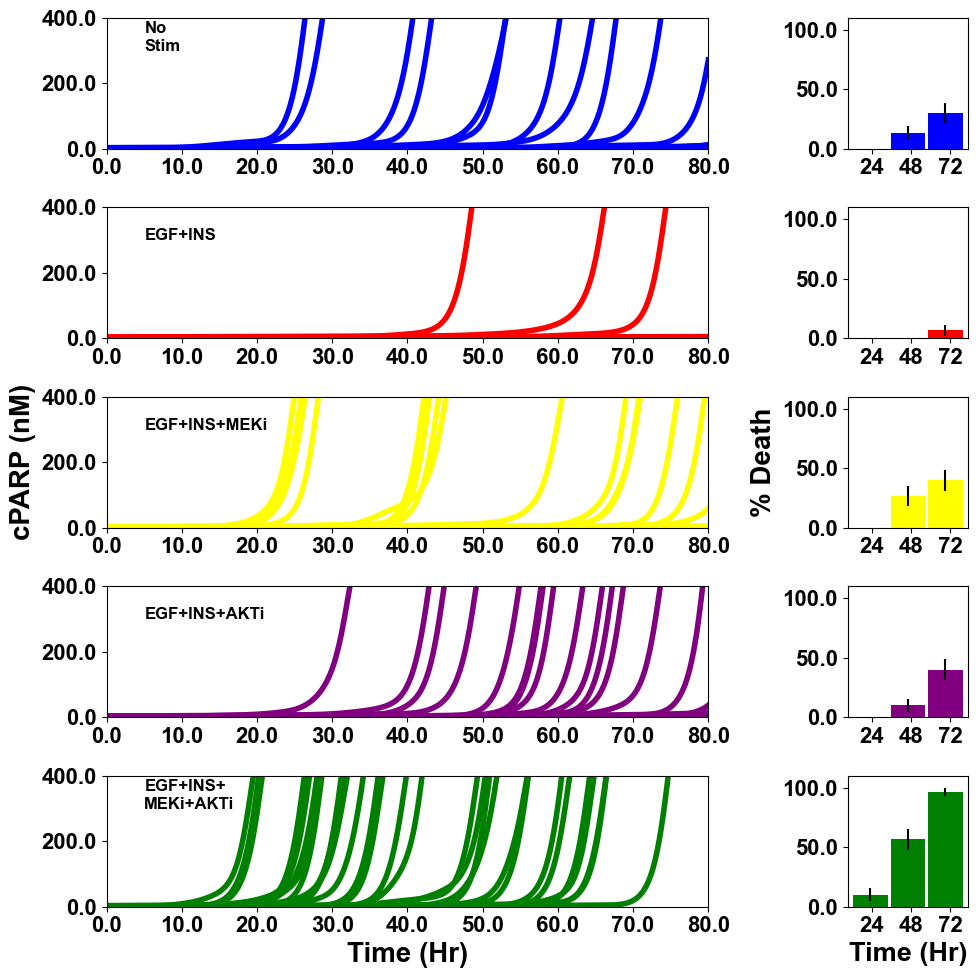

In [3]:
data_name = get_data_title()
data_file = f'inhibition-of-stochastic-apoptosis/results/{data_name}.pkl'
data = pd.read_pickle(data_file)

conds = ["GF_0","EGF_3p3_INS_1721","EGF_3p3_INS_1721_MEKi_10000", "EGF_3p3_INS_1721_AKTi_10000", "EGF_3p3_INS_1721_MEKi_10000AKTi_10000"]
tally = {cond: {"24":0, "48":0, "72": 0} for cond in conds}
errs = {cond: {"24":0, "48":0, "72": 0} for cond in conds}
ignores = ["serum_starved"]

for sim in data.keys():
    condition_id = data[sim]["conditionId"]
    cell = data[sim]["cell"]

    if condition_id in ignores:
        continue

    cparp = data[sim]["cPARP_total"]["simulation"].tolist()
    parp = data[sim]["PARP_total"]["simulation"].tolist()
    time = data[sim]["PARP_total"]["time"].tolist()

    idx_pair = zip(cparp, parp, time)
    dead_pos = None
    for idx, (c, p, t) in enumerate(idx_pair):
        if c > p:
            dead_pos = idx
            break

    if dead_pos:
        if time[dead_pos]/3600 <= 24:
            tally[condition_id]["24"] += 1
        if time[dead_pos]/3600 <= 48:
            tally[condition_id]["48"] += 1
        if time[dead_pos]/3600 <= 72:
            tally[condition_id]["72"] += 1
num_cells = 30 # Defined in benchmark YAML file
colors = ['blue', 'red', 'yellow', 'purple', 'green']
fig, ax = plt.subplots(5, 2, figsize=(10,10), width_ratios = [5,1])

for i in range(len(conds)):
    condition_id = conds[i]
    for sim in data.keys():
        if data[sim]["conditionId"] == condition_id:
            ax[i,0].plot(data[sim]["cPARP_total"]["time"]/3600, data[sim]["cPARP_total"]["simulation"].tolist(), 
                        color=colors[i], linewidth=4)

    dead_cells = [(val/num_cells)*100 for val in tally[condition_id].values()]
    std_err = np.array([np.sqrt((val * (100 - val)) / num_cells) for val in dead_cells])

    ax[i, 1].bar([24, 48, 72], dead_cells, color=colors[i], width=((72/3)-2), yerr=std_err)

    ax[i,0].set_ylim(0,400)
    ax[i,0].set_xlim(0,80)
    ax[i,0].set_xticklabels(ax[i,0].get_xticks(), fontsize=16, weight='bold')
    ax[i,0].set_yticklabels(ax[i,0].get_yticks(), fontsize=16, weight='bold')
    ax[i,1].set_ylim(0, 110)
    ax[i,1].set_yticklabels(ax[i,1].get_yticks(), fontsize=16, weight="bold")
    ax[i,1].set_xticklabels(["", "24", "48", "72"], fontsize=16, weight="bold")

ax[2,0].set_ylabel('cPARP (nM)', fontsize = 20, weight='bold')
ax[4,0].set_xlabel('Time (Hr)', fontsize=20, weight='bold')

ax[2, 1].set_ylabel('% Death', fontsize = 20, weight='bold')
ax[4, 1].set_xlabel('Time (Hr)', fontsize = 19.5, weight='bold')

ax[0,0].text(x=5.0, y=300, s='No\nStim', weight='bold', fontsize=12)
ax[1,0].text(x=5.0, y=300, s='EGF+INS', weight='bold', fontsize=12)
ax[2,0].text(x=5.0, y=300, s='EGF+INS+MEKi', weight='bold', fontsize=12)
ax[3,0].text(x=5.0, y=300, s='EGF+INS+AKTi', weight='bold', fontsize=12)
ax[4,0].text(x=5.0, y=300, s='EGF+INS+\nMEKi+AKTi', weight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(f'inhibition-of-stochastic-apoptosis/results/{data_name}.png', dpi=300)

### BIM Dependent ERK Inhibition Benchmark
[Compare to Erdem et al. Supp. Fig. 10a](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
ERK and AKT inhibition-induced cell death mechanisms are predominantly BIM dependent, not BAD dependent.

In [1]:
data_name = get_data_title()
with open(f'BIM-dependent-ERK-inhibition/results/{data_name}.pkl', 'rb') as f:
    data = pickle.load(f)

dead_cell_tally = {
    'BIM_total': 0, # benchmark condition Ids to find, list for how many pass threshold
    'BAD_total': 0
    }

for simulation in data.keys():
    
    condition_id = data[simulation]['conditionId']
    
    if condition_id not in list(dead_cell_tally.keys()):
        continue

    parp_lvl = data[simulation]['PARP_total']['simulation']
    cparp_lvl = data[simulation]['cPARP_total']['simulation']

    cell_dead = False

    for idx, val in enumerate(cparp_lvl):
        if val > parp_lvl[idx]:
            
            cell_dead = True

    if cell_dead:
        dead_cell_tally[condition_id] += 1

num_cells = 25 # see BIM-dependent-ERK-inhibition.yml for cell count

bad_dead_cells = dead_cell_tally['BAD_total']
bim_dead_cells = dead_cell_tally['BIM_total']

labels = ["BIM-dependent", "BAD-dependent"]
bad_percent = (bad_dead_cells / num_cells) * 100
bim_percent = (bim_dead_cells / num_cells) * 100

dead_cells = [bim_percent, bad_percent]
dc_sem_bad = np.sqrt((bad_dead_cells*(100-bad_dead_cells))/num_cells)
dc_sem_bim = np.sqrt((bim_dead_cells*(100-bim_dead_cells))/num_cells)
dc_sem = [dc_sem_bim, dc_sem_bad]
fig = plt.figure(figsize=(3, 4))
plt.bar(labels, dead_cells, yerr=dc_sem, capsize=5, color='blue')
plt.ylim(0, 100)
plt.yticks(np.arange(0, 120, 20), fontsize=16, weight='bold')
plt.ylabel('% Death', fontsize=16, weight='bold')
plt.xticks(ticks=range(len(dead_cells)), labels=labels,rotation=45, fontsize=16, weight='bold')
# plt.title('E + I @ 48 hours (SPARCED)', y=1.05)
plt.tight_layout()

plt.savefig(f'BIM-dependent-ERK-inhibition/results/{data_name}.png', dpi=300)

NameError: name 'get_data_title' is not defined

### Regulation of stochastic proliferation Benchmark
[Compare to Erdem et al. Supp. Fig. 10b](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
EGF and insulin cooperatively induce cell cycle entry, with insulin inducing very little cell cycle entry alone.

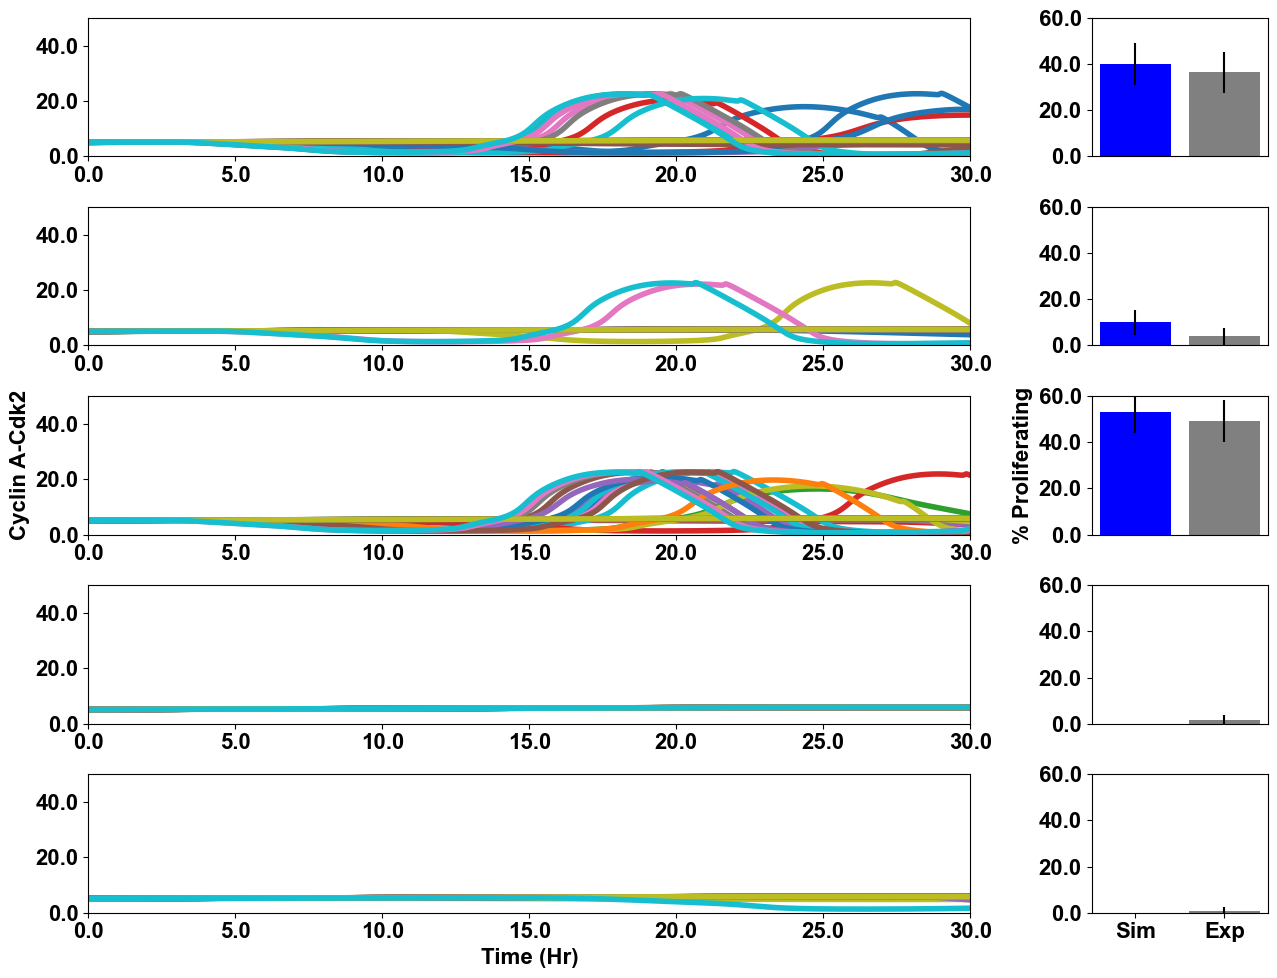

In [15]:
data_name = get_data_title()
data_file = f'regulation-of-stochastic-proliferation/results/{data_name}.pkl'
data = Helpers.load_data(data_file)
conds_registry = CellPopMetrics(data).get_registry()
del conds_registry['heterogenize']
cond_labels = ['EGF', 'INS', 'EGF+INS', 'EGF+INS+MEKi', 'EGF+INS+AKTi']

# Constants
SPHASE_THRESHOLD = 20 # Summation of Cyclin Complexes over the course of the simulation
CELLS_PER_CONDITION = 30 # Define the number of cells per condition

# Plotting
split_left_right = LeftRightSplit(nrows = 5, ncols = 2, figsize = (13, 10), width_ratios = [5,1])

split_left_right.plot_left(data=data, 
                           observable='cycA_Cdk2_total',
                           dependent_var='time', 
                           independent_var='simulation', 
                           conds_registry=conds_registry, 
                           colors = None, 
                           yaxis_limits=(0, 50), 
                           xaxis_limits=(0, 30))

sphase_ratios = CellPopMetrics(data=data).cells_above_threshold(observable='Sphase', 
                                                                    threshold= SPHASE_THRESHOLD, 
                                                                    experimental_data=True)

split_left_right.plot_right(sphase_ratios, 
                            error_bars=True, 
                            x_labels=['Sim', 'Exp'],
                            y_range=[0, 60], 
                            colors=['blue', 'grey'], 
                            CELLS_PER_CONDITION=CELLS_PER_CONDITION)

split_left_right.axes_left[2].set_ylabel('Cyclin A-Cdk2', fontsize=16, weight='bold')
split_left_right.axes_left[4].set_xlabel('Time (Hr)', fontsize = 16, weight = 'bold')

split_left_right.axes_right[2].set_ylabel('% Proliferating', fontsize = 16, weight = 'bold')
split_left_right.fig.tight_layout()
split_left_right.save_plot(f'regulation-of-stochastic-proliferation/results/{data_name}.png')


### Ribosome Doubling Rate Benchmark  
[Compare to Erdem et al. Supp. Fig. 8b](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
The number of ribosomes within the cell doubles within 24 h.

Enter the name of the simulation, default is date of (YYYY-MM-DD):  2026-09-17


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

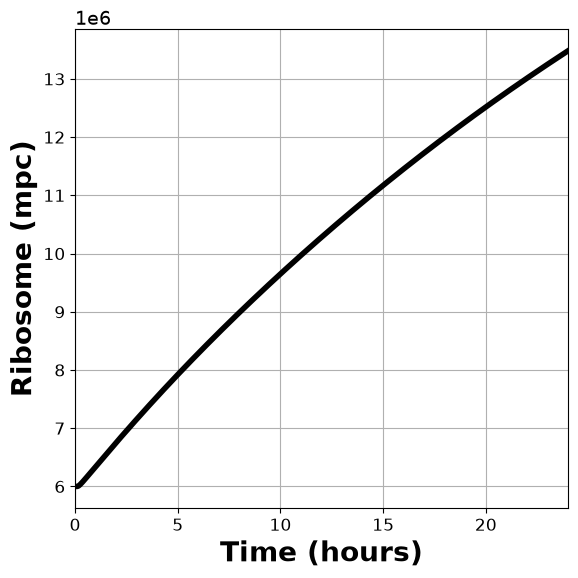

In [6]:
data_name = get_data_title()
with open(f'../ribosome-doubling-rate.pkl', 'rb') as f:
    data = pickle.load(f)
Vc = 5.25E-12
import matplotlib.ticker as ticker
conditions = []
for condition in data['ribosome-doubling-rate']:
    conditions.append(condition)

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(6, 6))
yy = np.array([value for value in data['ribosome-doubling-rate'][conditions[0]]['Ribosome_total']['simulation']])
tt = (data['ribosome-doubling-rate'][conditions[0]]['Ribosome_total']['time']/3600)

ax.plot(tt, yy, linewidth=4, color='black')
ax.set_xlim([0, 24])
ax.grid()
ax.set_ylabel('Ribosome (mpc)', fontsize=20, weight='bold')
ax.set_xlabel('Time (hours)', fontsize=20, weight='bold')

# Force scientific notation with desired exponent
ax.ticklabel_format(axis='y', style='sci', scilimits=(6,6))  # enforces 1E6
ax.yaxis.get_offset_text().set_fontsize(14)

plt.tight_layout()
plt.savefig(f'ribosome-doubling-rate.png')


### ERK and AKT Dose Dependent Responses Benchmark
[Compare to Erdem et al. Supp. fig 5](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
EGF and insulin stimulation activates both ERK and AKT pathways. Dual stimulation with the two ligands induces prolonged AKT activation.

Enter the name of the simulation, default is date of (YYYY-MM-DD):  ERK-AKT-dose-response


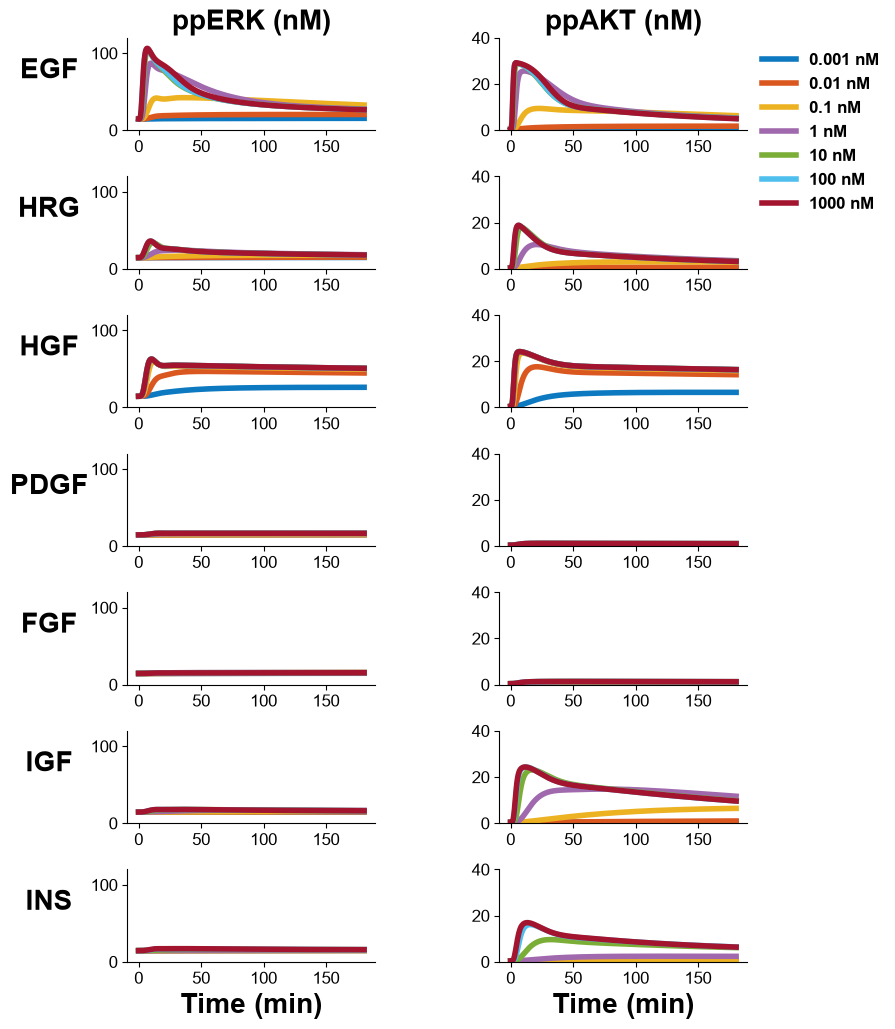

In [17]:
data_name = get_data_title()
with open(f'ERK-AKT-dose-response/results/{data_name}.pkl', 'rb') as f:
    data = pickle.load(f)

conditional_strings = ['EGF', 'HRG', 'HGF', 'PDGF', 'FGF', 'IGF', 'INS']
colors = ["#0d79c0", "#da5820",  "#edb222",  "#a169ad","#7bae37","#4fbfee", "#a3152f"]
fig, axes = plt.subplots(7, 2, figsize=(8, 12))
conditions = []
for condition in data['ERK-AKT-dose-response']:
    conditions.append(condition)

for i in range(7):
    upper = (i+1)*7
    lower = upper - 7
    for j in range(lower, upper):
        axes[i, 0].plot(data['ERK-AKT-dose-response'][conditions[j]]['ppERK_total']['time'] / 60, 
                        data['ERK-AKT-dose-response'][conditions[j]]['ppERK_total']['simulation'], linewidth=4, color=colors[j-lower])
        axes[i, 1].plot(data['ERK-AKT-dose-response'][conditions[j]]['ppAKT_total']['time'] / 60, 
                        data['ERK-AKT-dose-response'][conditions[j]]['ppAKT_total']['simulation'], linewidth=4, color=colors[j-lower])

    axes[i, 0].set_ylim(0, 120)
    axes[i, 1].set_ylim(0, 40)
    axes[i, 0].set_ylabel(conditional_strings[i], fontsize=20, weight='bold', labelpad=30, rotation=0)
    axes[i,0].spines[['right', 'top']].set_visible(False)
    axes[i,1].spines[['right', 'top']].set_visible(False)
axes[6, 0].set_xlabel('Time (min)', fontsize = 20, weight='bold')
axes[6, 1].set_xlabel('Time (min)', fontsize = 20, weight='bold')

axes[0,0].set_title('ppERK (nM)', fontsize = 20, weight='bold')

axes[0,1].set_title('ppAKT (nM)', fontsize = 20, weight='bold')

legend_values = ['0.001 nM', '0.01 nM', '0.1 nM', '1 nM', '10 nM', '100 nM', '1000 nM']
legend_properties = {'weight':'bold'}
axes[0, 1].legend(labels = legend_values, loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=20, prop=legend_properties)


# plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.5)

fig.savefig(f'ERK-AKT-dose-response/results/{data_name}.png', dpi=300, bbox_inches='tight')

## Validations Complete

## References:
* Erdem, C., Mutsuddy, A., Bensman, E.M. et al. A scalable, open-source implementation of a large-scale mechanistic model for single cell proliferation and death signaling. Nat Commun 13, 3555 (2022). [https://doi.org/10.1038/s41467-022-31138-1](https://doi.org/10.1038/s41467-022-31138-1)